## 基于规则引擎的工具

In [139]:
import re
from typing import Optional

# ==================== 数据字段定义 ====================
BRANDS = [
    "丰田",
    "本田",
    "福特",
    "雪佛兰",
    "日产",
    "宝马",
    "奔驰",
    "奥迪",
    "现代",
    "起亚",
]
MODELS = ["轿车", "SUV", "卡车", "两厢车", "跑车", "厢式车"]
COLORS = ["红色", "蓝色", "黑色", "白色", "银色", "灰色", "绿色"]
SALES_PERSONS = ["张三", "李四", "王五", "赵六", "孙七"]

# ==================== 规则引擎核心 ====================


class RuleEngine:
    """快速规则匹配引擎，用于意图识别和参数提取"""

    def __init__(self):
        self.brands = BRANDS
        self.models = MODELS
        self.colors = COLORS
        self.sales_persons = SALES_PERSONS

    def match(self, query: str) -> tuple[Optional[str], dict]:
        """匹配用户输入，返回 (意图, 参数)"""
        query = query.strip()

        # 初始化参数
        params = {}
        intent = "query_car"

        # 1. 提取价格区间
        price_params = self._extract_price(query)
        params.update(price_params)

        # 2. 提取品牌
        for brand in self.brands:
            if brand in query:
                params["brand"] = brand
                break

        # 3. 提取车型
        for model in self.models:
            if model in query:
                params["model"] = model
                break

        # 4. 提取颜色
        for color in self.colors:
            if color in query:
                params["color"] = color
                break

        # 5. 提取销售员
        for sp in self.sales_persons:
            if sp in query:
                params["sales_person"] = sp
                break

        # 判断是否有查询意图
        if any(
            [
                k in params
                for k in [
                    "brand",
                    "model",
                    "color",
                    "sales_person",
                    "min_price",
                    "max_price",
                ]
            ]
        ):
            return intent, params

        # 6. 检查销售员统计
        if any(word in query for word in ["销售员", "谁卖", "业绩", "排名"]):
            return "query_salesperson", {}

        return None, {}

    def _extract_price(self, query: str) -> dict:
        """提取价格区间参数"""
        params = {}

        # 匹配 "价格XX至YY" 或 "价格XX到YY"
        m = re.search(r"价格\s*(\d+(?:\.\d+)?)\s*(?:至|到)\s*(\d+(?:\.\d+)?)", query)
        if m:
            params["min_price"] = float(m.group(1))
            params["max_price"] = float(m.group(2))
            return params

        # 匹配 "不超过XX万" 或 "XX万以下"
        m = re.search(r"(?:不超过|低于|以下)\s*(\d+(?:\.\d+)?)\s*万", query)
        if m:
            params["max_price"] = float(m.group(1)) * 10000
            return params

        # 匹配 "不低于XX万" 或 "XX万以上"
        m = re.search(r"(?:不低于|高于|以上)\s*(\d+(?:\.\d+)?)\s*万", query)
        if m:
            params["min_price"] = float(m.group(1)) * 10000
            return params

        return params

    def build_response(self, query: str, df) -> str:
        """根据规则匹配结果构建响应"""
        intent, params = self.match(query)

        if intent is None:
            return "无法理解您的查询，请尝试：查询丰田轿车、红色SUV等"

        if intent == "query_car":
            return self._query_car(df, params)
        elif intent == "query_salesperson":
            return self._query_by_salesperson(df)

        return "未知意图"

    def _query_car(self, df, params) -> str:
        """查询车辆数据"""
        result = df.copy()

        if "brand" in params:
            result = result[result["品牌"] == params["brand"]]
        if "model" in params:
            result = result[result["车型"] == params["model"]]
        if "color" in params:
            result = result[result["颜色"] == params["color"]]
        if "sales_person" in params:
            result = result[result["销售员"] == params["sales_person"]]
        if "min_price" in params:
            result = result[result["价格"] >= params["min_price"]]
        if "max_price" in params:
            result = result[result["价格"] <= params["max_price"]]

        if result.empty:
            return "未找到匹配的数据"

        limit = params.get("limit", 10)
        result = result.head(limit)

        return f"找到 {len(result)} 条记录：\n{result.to_string(index=False)}"

    def _query_by_salesperson(self, df) -> str:
        """按销售员统计"""
        sp_stats = df.groupby("销售员").agg({"价格": ["count", "sum", "mean"]}).round(2)
        sp_stats.columns = ["销量", "总销售额", "平均单价"]
        sp_stats = sp_stats.sort_values("总销售额", ascending=False)

        return f"销售员业绩排名：\n{sp_stats.to_string()}"


# ==================== 测试规则引擎 ====================
engine = RuleEngine()

test_queries = [
    "查询丰田轿车",
    "红色SUV有哪些",
    "价格在5万至8万之间",
    "宝马的价格",
    "不超过6万的车有哪些",
    "哪个销售员卖得最多",
]

print("=== 规则引擎测试 ===\n")
for q in test_queries:
    intent, params = engine.match(q)
    print(f"查询: {q}")
    print(f"意图: {intent}, 参数: {params}")
    print(f"结果: {engine.build_response(q, df)}\n")

=== 规则引擎测试 ===

查询: 查询丰田轿车
意图: query_car, 参数: {'brand': '丰田', 'model': '轿车'}
结果: 找到 10 条记录：
        日期 品牌 车型 颜色   年份       价格      里程  排量   油耗 销售员
2022-01-04 丰田 轿车 蓝色 2017 41937.10 28489.0 3.5 27.4  赵六
2022-01-10 丰田 轿车 灰色 2020 62527.13 35653.0 3.5 39.1  赵六
2022-06-01 丰田 轿车 蓝色 2022 23743.94 12852.0 1.6 20.8  赵六
2022-06-02 丰田 轿车 黑色 2017 32525.86 42614.0 2.0 40.0  赵六
2022-11-01 丰田 轿车 蓝色 2018 28588.60 10588.0 4.0 32.7  张三
2023-01-16 丰田 轿车 银色 2017 30671.27 14599.0 1.6 33.1  赵六
2023-05-09 丰田 轿车 银色 2022 44286.13 69429.0 3.0 38.5  赵六
2023-07-26 丰田 轿车 蓝色 2018 79676.32 63161.0 2.0 25.7  赵六
2023-08-05 丰田 轿车 红色 2019 39739.83 96895.0 2.5 30.1  孙七
2023-08-08 丰田 轿车 黑色 2017 61659.95 70286.0 4.0 37.8  孙七

查询: 红色SUV有哪些
意图: query_car, 参数: {'model': 'SUV', 'color': '红色'}
结果: 找到 10 条记录：
        日期 品牌  车型 颜色   年份       价格      里程  排量   油耗 销售员
2022-02-05 起亚 SUV 红色 2022 48640.61 75818.0 3.0 27.8  李四
2022-02-11 起亚 SUV 红色 2019 59549.01 95638.0 4.0 28.9  赵六
2022-04-27 奔驰 SUV 红色 2019 32673.27 29724.0 2.5 31.8  张三

## 规则引擎实现

In [140]:
from langchain_agent.agents.base import get_singleton_client

basic_model = get_singleton_client(llm_provider="longcat")
advanced_model = get_singleton_client(llm_provider="bailing")

## 生成汽车销售模拟数据

In [141]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 生成样本数据
n_rows = 1000

# 生成日期
start_date = datetime(2022, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(n_rows)]

# 定义数据类别（中文）
makes = [
    "丰田",
    "本田",
    "福特",
    "雪佛兰",
    "日产",
    "宝马",
    "奔驰",
    "奥迪",
    "现代",
    "起亚",
]
models = ["轿车", "SUV", "卡车", "两厢车", "跑车", "厢式车"]
colors = ["红色", "蓝色", "黑色", "白色", "银色", "灰色", "绿色"]
sales_persons = ["张三", "李四", "王五", "赵六", "孙七"]

# 创建数据集
data = {
    "日期": dates,
    "品牌": np.random.choice(makes, n_rows),
    "车型": np.random.choice(models, n_rows),
    "颜色": np.random.choice(colors, n_rows),
    "年份": np.random.randint(2015, 2023, n_rows),
    "价格": np.random.uniform(20000, 80000, n_rows).round(2),
    "里程": np.random.uniform(0, 100000, n_rows).round(0),
    "排量": np.random.choice([1.6, 2.0, 2.5, 3.0, 3.5, 4.0], n_rows),
    "油耗": np.random.uniform(20, 40, n_rows).round(1),
    "销售员": np.random.choice(sales_persons, n_rows),
}

# 创建 DataFrame 并按日期排序
df = pd.DataFrame(data).sort_values("日期")


# 创建数据集
data = {
    "日期": dates,
    "品牌": np.random.choice(makes, n_rows),
    "车型": np.random.choice(models, n_rows),
    "颜色": np.random.choice(colors, n_rows),
    "年份": np.random.randint(2015, 2023, n_rows),
    "价格": np.random.uniform(20000, 80000, n_rows).round(2),
    "里程": np.random.uniform(0, 100000, n_rows).round(0),
    "排量": np.random.choice([1.6, 2.0, 2.5, 3.0, 3.5, 4.0], n_rows),
    "油耗": np.random.uniform(20, 40, n_rows).round(1),
    "销售员": np.random.choice(sales_persons, n_rows),
}

# 创建 DataFrame 并按日期排序
df = pd.DataFrame(data).sort_values("日期")

# 显示数据样本和统计信息
print("\n数据前几行：")
print(df.head())

print("\n数据信息：")
df.info()

print("\n数据统计摘要：")
print(df.describe())


数据前几行：
          日期  品牌   车型  颜色    年份        价格       里程   排量    油耗 销售员
0 2022-01-01  奥迪   轿车  红色  2015  54027.72  19355.0  4.0  29.2  赵六
1 2022-01-02  奔驰   卡车  灰色  2019  43477.22    475.0  3.0  38.5  赵六
2 2022-01-03  宝马   跑车  红色  2016  50606.75  42383.0  1.6  34.0  孙七
3 2022-01-04  日产  厢式车  红色  2022  43218.73  70138.0  1.6  23.7  王五
4 2022-01-05  福特   跑车  黑色  2018  44454.69   9347.0  2.5  36.6  张三

数据信息：
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   日期      1000 non-null   datetime64[us]
 1   品牌      1000 non-null   str           
 2   车型      1000 non-null   str           
 3   颜色      1000 non-null   str           
 4   年份      1000 non-null   int64         
 5   价格      1000 non-null   float64       
 6   里程      1000 non-null   float64       
 7   排量      1000 non-null   float64       
 8   油耗      1000 non-null   float64       
 9   销售员  

In [142]:
# 系统提示词配置
SYSTEM_PROMPT = """
你是一个汽车销售数据分析助手，可以帮助用户查询和分析汽车销售数据。

## 可查询的字段
- 日期：销售日期
- 品牌：汽车品牌（丰田、本田、福特、雪佛兰、日产、宝马、奔驰、奥迪、现代、起亚）
- 车型：汽车类型（轿车、SUV、卡车、两厢车、跑车、厢式车）
- 颜色：车身颜色（红色、蓝色、黑色、白色、银色、灰色、绿色）
- 年份：出厂年份（2015-2022）
- 价格：成交价格（元）
- 里程：行驶里程（公里）
- 排量：发动机排量（L）
- 油耗：百公里油耗（L）
- 销售员：销售人员（张三、李四、王五、赵六、孙七）

## 可用工具
1. query_car_data: 根据多条件查询汽车销售数据
   - brand: 品牌名称
   - model: 车型
   - color: 颜色
   - sales_person: 销售员
   - min_price: 最低价格
   - max_price: 最高价格
   - limit: 返回记录数

## 示例问题
- "查询丰田轿车的价格"
- "红色SUV有哪些？"
- "张三卖得最好的车是什么品牌？"
- "价格在5万到8万之间的有哪些？"

每次只调用一个工具，解决用户的问题。
"""

In [143]:
from langchain.tools import tool


@tool
def rule_based_query(query: str, limit: int = 10) -> str:
    """基于规则引擎的智能查询工具

    自动从用户输入中识别查询意图和参数，无需手动指定。

    Args:
        query: 自然语言查询（如："丰田轿车"、"红色SUV"、"价格在5万至8万"）
        limit: 返回的最大记录数，默认为 10
    """
    intent, params = engine.match(query)
    params["limit"] = limit

    if intent is None:
        return "无法理解您的查询，请尝试：查询丰田轿车、红色SUV等"

    if intent == "query_car":
        return engine._query_car(df, params)
    elif intent == "query_salesperson":
        return engine._query_by_salesperson(df)

    return "未知意图"


@tool
def query_car_data(
    brand: str = None,
    model: str = None,
    color: str = None,
    sales_person: str = None,
    min_price: float = None,
    max_price: float = None,
    limit: int = 10,
) -> str:
    """查询汽车销售数据

    根据条件筛选数据并返回结果，支持多条件组合。

    Args:
        brand: 品牌名称（如：丰田、本田、宝马）
        model: 车型（如：轿车、SUV、卡车）
        color: 颜色（如：红色、蓝色、黑色）
        sales_person: 销售员（如：张三、李四）
        min_price: 最低价格（元）
        max_price: 最高价格（元）
        limit: 返回的最大记录数，默认为 10
    """
    print("调用语义工具")
    # 复制避免修改原数据
    result = df.copy()

    # 应用筛选条件
    if brand:
        result = result[result["品牌"] == brand]
    if model:
        result = result[result["车型"] == model]
    if color:
        result = result[result["颜色"] == color]
    if sales_person:
        result = result[result["销售员"] == sales_person]
    if min_price is not None:
        result = result[result["价格"] >= min_price]
    if max_price is not None:
        result = result[result["价格"] <= max_price]

    # 限制结果数量
    result = result.head(limit)

    if result.empty:
        return "未找到匹配的数据"

    return f"找到 {len(result)} 条记录：\n{result.to_string(index=False)}"


# 测试工具
query_car_data.invoke({"brand": "丰田", "model": "轿车", "limit": 5})

调用语义工具


'找到 5 条记录：\n        日期 品牌 车型 颜色   年份       价格      里程  排量   油耗 销售员\n2022-05-06 丰田 轿车 红色 2020 41690.55 74515.0 2.0 35.3  张三\n2022-10-17 丰田 轿车 白色 2022 79561.63 94527.0 1.6 31.7  孙七\n2022-12-05 丰田 轿车 灰色 2018 38957.76 89819.0 3.0 36.2  张三\n2022-12-26 丰田 轿车 红色 2020 34131.91  1835.0 2.0 26.2  孙七\n2023-06-08 丰田 轿车 灰色 2015 45085.08 84942.0 3.0 28.1  李四'

In [144]:
from langchain.agents import create_agent

agent = create_agent(
    basic_model,
    tools=[rule_based_query],
    # system_prompt=SYSTEM_PROMPT,
)

In [145]:
from langchain.messages import SystemMessage, AIMessage, HumanMessage

agent.invoke(
    {"messages": [HumanMessage("张三卖了多少辆车？")]},
)

{'messages': [HumanMessage(content='张三卖了多少辆车？', additional_kwargs={}, response_metadata={}, id='8c613764-bae1-4332-b998-190d524de453'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 296, 'total_tokens': 322, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'cache_write_tokens': 0, 'cache_read_tokens': 0, 'input_tokens': 0, 'output_tokens': 0, 'output_tokens_details': None, 'cached_tokens': 0}, 'model_provider': 'openai', 'model_name': 'LongCat-Flash-Chat', 'system_fingerprint': None, 'id': '282180d2042148c7a916f7c186450d89', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e10d9-754a-7bb3-b42d-e5d2d0eb76e8-0', tool_calls=[{'name': 'rule_based_query', 'args': {'query': '张三卖了多少辆车'}, 'id': 'call_570d71a0ab5c4289a5a0d4eb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 296, 'output_tokens': 26, 'total_tokens': 322, 'input_token_details'

## 基于workflow工作流的做法

In [146]:
# 系统提示词配置
SYSTEM_PROMPT = """
你是一个汽车销售数据分析助手，可以帮助用户查询和分析汽车销售数据。

## 可查询的字段
- 日期：销售日期
- 品牌：汽车品牌（丰田、本田、福特、雪佛兰、日产、宝马、奔驰、奥迪、现代、起亚）
- 车型：汽车类型（轿车、SUV、卡车、两厢车、跑车、厢式车）
- 颜色：车身颜色（红色、蓝色、黑色、白色、银色、灰色、绿色）
- 年份：出厂年份（2015-2022）
- 价格：成交价格（元）
- 里程：行驶里程（公里）
- 排量：发动机排量（L）
- 油耗：百公里油耗（L）
- 销售员：销售人员（张三、李四、王五、赵六、孙七）

## 示例问题
- "查询丰田轿车的价格"
- "红色SUV有哪些？"
- "张三卖得最好的车是什么品牌？"
- "价格在5万到8万之间的有哪些？"
"""

# 系统提示词配置
SYSTEM_PROMPT_TOOL = """
你是一个汽车销售数据分析助手，可以帮助用户查询和分析汽车销售数据。

## 可查询的字段
- 日期：销售日期
- 品牌：汽车品牌（丰田、本田、福特、雪佛兰、日产、宝马、奔驰、奥迪、现代、起亚）
- 车型：汽车类型（轿车、SUV、卡车、两厢车、跑车、厢式车）
- 颜色：车身颜色（红色、蓝色、黑色、白色、银色、灰色、绿色）
- 年份：出厂年份（2015-2022）
- 价格：成交价格（元）
- 里程：行驶里程（公里）
- 排量：发动机排量（L）
- 油耗：百公里油耗（L）
- 销售员：销售人员（张三、李四、王五、赵六、孙七）

## 可用工具
1. query_car_data: 根据多条件查询汽车销售数据
   - brand: 品牌名称
   - model: 车型
   - color: 颜色
   - sales_person: 销售员
   - min_price: 最低价格
   - max_price: 最高价格
   - limit: 返回记录数

## 示例问题
- "查询丰田轿车的价格"
- "红色SUV有哪些？"
- "张三卖得最好的车是什么品牌？"
- "价格在5万到8万之间的有哪些？"

每次只调用一个工具，解决用户的问题。
"""

In [147]:
## 节点
from langgraph.graph import MessagesState


class State(MessagesState):
    is_true: bool = False


def rule_based_query_node(state: State) -> str:
    """基于规则引擎的智能查询工具

    自动从用户输入中识别查询意图和参数，无需手动指定。

    """
    messages = state["messages"]
    query = next(
        (m.content for m in reversed(messages) if isinstance(m, HumanMessage)), None
    )
    if not query:
        return {"messages": [AIMessage("用户输入内容为空")], "is_true": False}

    intent, params = engine.match(query)
    params["limit"] = 10

    if intent is None:
        return {
            "messages": [
                AIMessage("无法理解您的查询，请尝试：查询丰田轿车、红色SUV等")
            ],
            "is_true": False,
        }

    if intent == "query_car":
        return {"messages": [AIMessage(engine._query_car(df, params))], "is_true": True}
    elif intent == "query_salesperson":
        return {
            "messages": [AIMessage(engine._query_by_salesperson(df))],
            "is_true": True,
        }

    return {"messages": [AIMessage("未知意图")], "is_true": False}

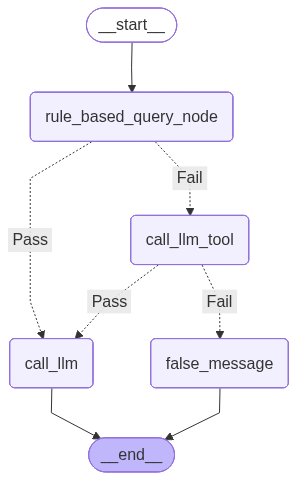

In [148]:
from langgraph.graph import StateGraph, MessagesState, START, END


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if state["is_true"]:
        return "Pass"
    return "Fail"


def call_llm(state: State):
    messages = state["messages"]
    messages = [SystemMessage(SYSTEM_PROMPT)] + messages
    ai_message = basic_model.invoke(messages)

    return {"messages": [ai_message]}


def false_message(state: State):
    return {"messages": [AIMessage("暂时无法回答您的问题。")]}


def call_llm_tool(state: State):
    messages = state["messages"]
    print(f"messages type: {type(messages)}")
    print(f"messages content: {messages}")
    query = next(
        (m.content for m in reversed(messages) if isinstance(m, HumanMessage)), None
    )
    print(f"query: {query}")
    messages = [SystemMessage(SYSTEM_PROMPT_TOOL), HumanMessage(query)]
    basic_model_tools = basic_model.bind_tools([query_car_data])

    response = basic_model_tools.invoke(messages)

    toll_messages = []
    if response.tool_calls:
        for tool_call in response.tool_calls:
            toll_message = query_car_data.invoke(tool_call)
            toll_messages.append(toll_message)
        return {"messages": toll_messages, "is_true": True}

    return {"is_true": False}


def check_punchline_tool(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if state["is_true"]:
        return "Pass"
    return "Fail"


graph = StateGraph(State)
graph.add_node(rule_based_query_node)
graph.add_node(false_message)
graph.add_node(call_llm)
graph.add_node(call_llm_tool)

graph.add_edge(START, "rule_based_query_node")
graph.add_conditional_edges(
    "rule_based_query_node",
    check_punchline,
    {"Fail": "call_llm_tool", "Pass": "call_llm"},
)
graph.add_conditional_edges(
    "call_llm_tool", check_punchline_tool, {"Fail": "false_message", "Pass": "call_llm"}
)

graph.add_edge("false_message", END)
graph.add_edge("call_llm", END)
graph = graph.compile()

graph

In [150]:
graph.invoke(
    {"messages": [HumanMessage("今天天气怎么样？")]},
)

messages type: <class 'list'>
messages content: [HumanMessage(content='今天天气怎么样？', additional_kwargs={}, response_metadata={}, id='0db29986-d9b7-47dd-a727-14ffb1e8b3be'), AIMessage(content='无法理解您的查询，请尝试：查询丰田轿车、红色SUV等', additional_kwargs={}, response_metadata={}, id='19f64546-f8fb-4b75-a23b-3f40d0c34ab4', tool_calls=[], invalid_tool_calls=[])]
query: 今天天气怎么样？


{'messages': [HumanMessage(content='今天天气怎么样？', additional_kwargs={}, response_metadata={}, id='0db29986-d9b7-47dd-a727-14ffb1e8b3be'),
  AIMessage(content='无法理解您的查询，请尝试：查询丰田轿车、红色SUV等', additional_kwargs={}, response_metadata={}, id='19f64546-f8fb-4b75-a23b-3f40d0c34ab4', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='暂时无法回答您的问题。', additional_kwargs={}, response_metadata={}, id='c376d0d2-824c-4e1e-9d5a-ae1263e3a287', tool_calls=[], invalid_tool_calls=[])],
 'is_true': False}